In this notebook we explore Gaussian Process Latent Variable Models (GPLVM) from Pyro for processing ESR data. GPLVM combines latent variable models with GPs to learn lower-dimensional representations while enabling precise spectra -> temperature mapping across measurement cycles.

In [10]:
# import modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, grid, tight_layout
import datetime

# Make the Jupyter Notebook fill 90 percent of the screen
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 90% !important; }</style>"))

# PyTorch
import torch
from torch.optim import Adam as TorchAdam
torch.set_default_dtype(torch.float64)

# Pyro
import pyro
import pyro.optim as optim
import pyro.contrib.gp as gp
from pyro.infer import SVI, TraceMeanField_ELBO
pyro.clear_param_store()

# GPLVM + kernels + models
from pyro.contrib.gp.models import GPLVM, SparseGPRegression
from pyro.contrib.gp.kernels import RBF

# preprocessing
from sklearn.preprocessing import MinMaxScaler

# warnings
import warnings
warnings.filterwarnings("ignore")

Index(['Unnamed: 0', 'frequency', '25up', '30up', '35up', '40down', '45down',
       '50', '45', '40', '35', '30', '25', '20'],
      dtype='object')


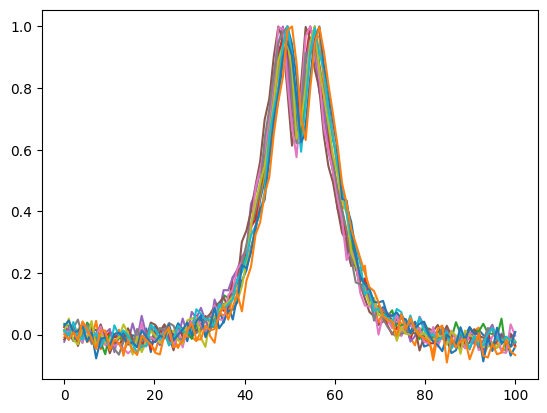

In [2]:
# load cycle 1 data and preprocess it 

temps_ = ['25', '30', '35',
       '40', '45', '50', '45', '40', '35', '30', '25', '20']
c1_temps = np.array(temps_, dtype=float)

## import data file
fpath = '../../esr_data/saved_data/cycle1'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, :-1]
df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', "-20"], inplace= True)
print(df.columns)
# df.iloc[:, 2:].plot(legend= False)
plt.show()
# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 2:]

#scale x axis to 0-100
sc = MinMaxScaler()
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten()*100

# plot baseline subtracted  y data
y_esr_c1 = y_esr.apply(lambda x: x - x[:10].mean())#+0.01
y_esr_c1 = y_esr_c1/y_esr_c1.min()
y_esr_c1 = y_esr_c1.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr_c1);
#plt.xlim(40, 80)


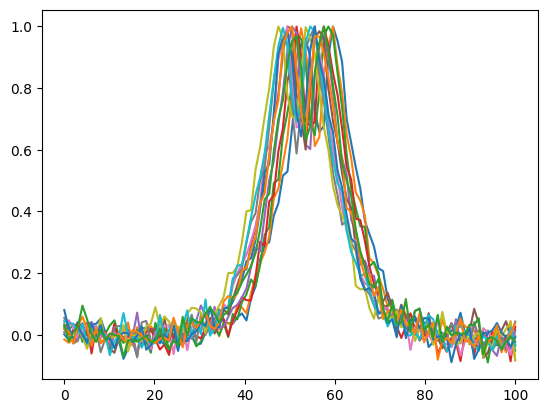

In [3]:
# load cycle 2 data and preprocess it 

temps_ = ['-30', '-20', '-10', '0',
       '10', '20', '30', '40', '50', '40', '30', '20',
       '10', '0', '-10', '-20', '-30']

c2_temps = np.array(temps_[:-4], dtype=float)


## import data file
fpath = '../../esr_data/saved_data/cycle2'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, 1:-4]
#df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace= True)
# df.iloc[:, 2:].plot(legend= False)
plt.show()
# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr_c2 = df.iloc[:, 1:]

# plt.plot(x_scale, y_esr_c2); plt.show()
#plt.xlim(40, 80)

y_esr_c2 = y_esr_c2.apply(lambda x: x - x[:20].mean())#+0.01
y_esr_c2 = y_esr_c2/y_esr_c2.min()
y_esr_c2 = y_esr_c2.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr_c2);



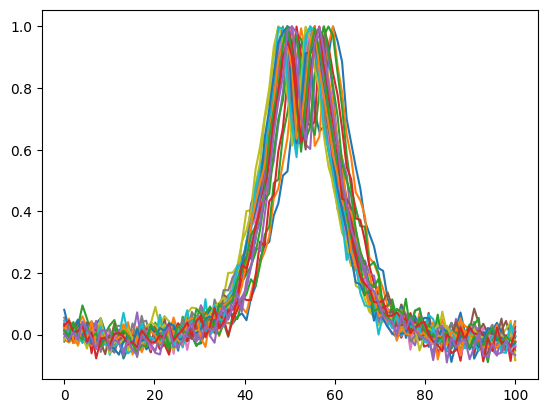

In [4]:
plt.plot(x_scale, y_esr_c2);
plt.plot(x_scale, y_esr_c1);

In [14]:
# Convert to torch tensors for GP: Train on Cycle 2, Test on Cycle 1
X_train = torch.tensor(y_esr_c2.T.values, dtype=torch.float64)
y_train = torch.tensor(c2_temps, dtype=torch.float64)
X_test = torch.tensor(y_esr_c1.T.values, dtype=torch.float64)
y_test = torch.tensor(c1_temps, dtype=torch.float64)

print(f"Training data (C2): X shape {X_train.shape}, y shape {y_train.shape}")
print(f"Test data (C1): X shape {X_test.shape}, y shape {y_test.shape}")

Training data (C2): X shape torch.Size([13, 100]), y shape torch.Size([13])
Test data (C1): X shape torch.Size([12, 100]), y shape torch.Size([12])


In [15]:
# Initialize GP regression model with spectral features as inputs
# Don't use GPLVM - instead use SparseGPRegression directly

# Create inducing points in spectral feature space
num_inducing = min(32, X_train.shape[0] // 2)
Uu_init = torch.randn(num_inducing, X_train.shape[1]) * 0.1

# Define RBF kernel for feature space
kernel = RBF(input_dim=X_train.shape[1])

# Reshape y_train to (output_dim, num_data_points) format expected by Pyro
y_train_gp = y_train.unsqueeze(0)  # Shape: (1, 13) - 1 output dimension, 13 data points

# Create SparseGPRegression model directly on spectral features
model = SparseGPRegression(
    X=X_train,  # Shape: (13, 100) - spectral features as direct input
    y=y_train_gp,  # Shape: (1, 13)
    kernel=kernel,
    Xu=Uu_init,  # Inducing points in feature space
    noise=torch.tensor(0.01),
    jitter=1e-5
)

print(f"SparseGPRegression initialized for spectral feature regression")
print(f"Data shapes - X: {X_train.shape}, y: {y_train_gp.shape}")
print(f"Inducing points shape: {Uu_init.shape}")

SparseGPRegression initialized for spectral feature regression
Data shapes - X: torch.Size([13, 100]), y: torch.Size([1, 13])
Inducing points shape: torch.Size([6, 100])


In [16]:
### Fit GP on C2 and make predictions on C1

# Reset parameter store
pyro.clear_param_store()

# Create SVI optimizer using Pyro's optimizer wrapper
optimizer = optim.Adam({"lr": 0.01})

# Create the ELBO loss function
elbo = TraceMeanField_ELBO()

# Setup SVI
svi = SVI(model.model, model.guide, optimizer, loss=elbo)

# Training loop
num_steps = 200
losses = []

print("Training SparseGPRegression...")
for step in range(num_steps):
    loss = svi.step()
    
    if step % 40 == 0:
        print(f"Step {step}: Loss = {loss:.4f}")
        losses.append(loss)

print(f"Training complete! Final loss: {loss:.4f}")

# Make predictions on test set (C1) using learned model
with torch.no_grad():
    model.set_mode("guide")
    mu, var = model(X_test)
    
    mu = mu.squeeze().numpy().flatten()
    std = np.sqrt(var.squeeze().numpy().flatten())

Training SparseGPRegression...
Step 0: Loss = 494661.5106
Step 40: Loss = 15374.0621
Step 80: Loss = 5887.1701
Step 120: Loss = 4312.9406
Step 160: Loss = 3528.3103
Training complete! Final loss: 3086.7270


In [17]:
# Performance metrics for C2->C1
mae_c2_c1 = np.mean(np.abs(mu - y_test.numpy()))
rmse_c2_c1 = np.sqrt(np.mean((mu - y_test.numpy())**2))
print(f"Mean Absolute Error: {mae_c2_c1:.4f} °C")
print(f"RMSE: {rmse_c2_c1:.4f} °C")
print(f"Mean prediction std: {np.mean(std):.6f}")

Mean Absolute Error: 1.1496 °C
RMSE: 1.3634 °C
Mean prediction std: 0.887218


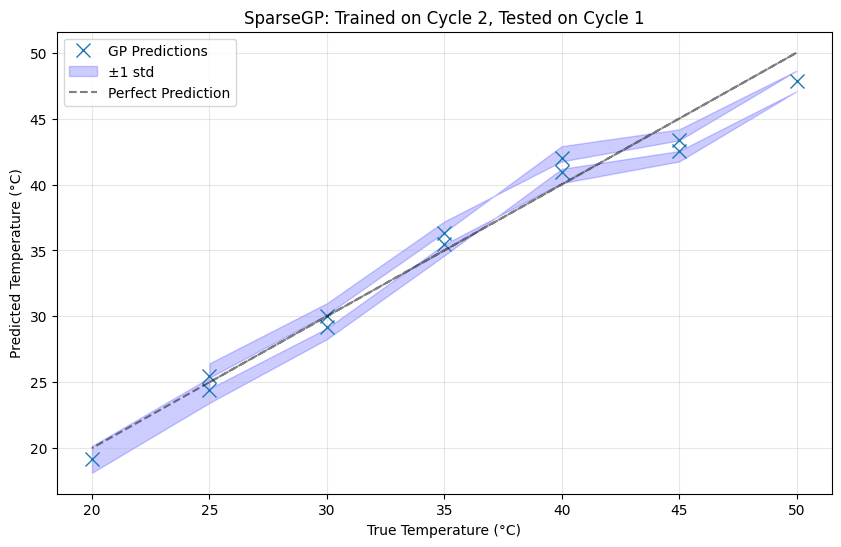

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.numpy(), mu, 'x', label='GP Predictions', markersize=10)
plt.fill_between(y_test.numpy(), mu - std, mu + std, alpha=0.2, color='blue', label='±1 std')
plt.plot(y_test.numpy(), y_test.numpy(), 'k--', alpha=0.5, label='Perfect Prediction')
plt.xlabel('True Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('SparseGP: Trained on Cycle 2, Tested on Cycle 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Flip Training and Testing Cycles (Train on C1, Test on C2)


Flipped configuration:
Training data (C1): X shape torch.Size([12, 100]), y shape torch.Size([12])
Test data (C2): X shape torch.Size([13, 100]), y shape torch.Size([13])

Training SparseGPRegression (flipped)...
Step 0: Loss = 778852.8843
Step 40: Loss = 13678.7741
Step 80: Loss = 6047.4753
Step 120: Loss = 4350.0245
Step 160: Loss = 3538.9503
Training (flipped) complete! Final loss: 3010.6653

Flipped Model Performance:
Mean Absolute Error: 10.2435 °C
RMSE: 15.7307 °C
Mean prediction std: 1.097035


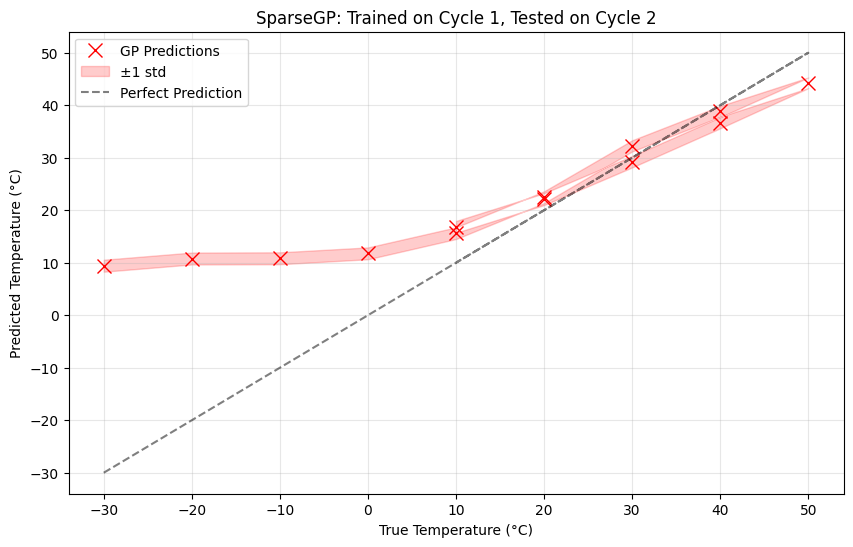

In [19]:
# Setup flipped training and test data: Train on Cycle 1, Test on Cycle 2
X_train_flipped = torch.tensor(y_esr_c1.T.values, dtype=torch.float64)
y_train_flipped = torch.tensor(c1_temps, dtype=torch.float64)
X_test_flipped = torch.tensor(y_esr_c2.T.values, dtype=torch.float64)
y_test_flipped = torch.tensor(c2_temps, dtype=torch.float64)

print(f"\nFlipped configuration:")
print(f"Training data (C1): X shape {X_train_flipped.shape}, y shape {y_train_flipped.shape}")
print(f"Test data (C2): X shape {X_test_flipped.shape}, y shape {y_test_flipped.shape}")

### Train GP on C1 and make predictions on C2

# Reset parameter store
pyro.clear_param_store()

# Initialize new model for flipped data
Uu_init_flipped = torch.randn(num_inducing, X_train_flipped.shape[1]) * 0.1

# Reshape y_train_flipped to (output_dim, num_data_points) format
y_train_flipped_gp = y_train_flipped.unsqueeze(0)  # Shape: (1, N_c1)

# Create SparseGPRegression model for flipped data
model_flipped = SparseGPRegression(
    X=X_train_flipped,
    y=y_train_flipped_gp,
    kernel=RBF(input_dim=X_train_flipped.shape[1]),
    Xu=Uu_init_flipped,
    noise=torch.tensor(0.01),
    jitter=1e-5
)

# Setup SVI for flipped model
optimizer_flipped = optim.Adam({"lr": 0.01})
elbo_flipped = TraceMeanField_ELBO()
svi_flipped = SVI(model_flipped.model, model_flipped.guide, optimizer_flipped, loss=elbo_flipped)

# Training loop for flipped model
print("\nTraining SparseGPRegression (flipped)...")
losses_flipped = []

for step in range(num_steps):
    loss = svi_flipped.step()
    
    if step % 40 == 0:
        print(f"Step {step}: Loss = {loss:.4f}")
        losses_flipped.append(loss)

print(f"Training (flipped) complete! Final loss: {loss:.4f}")

# Make predictions on test set (C2)
with torch.no_grad():
    model_flipped.set_mode("guide")
    mu_flipped, var_flipped = model_flipped(X_test_flipped)
    
    mu_flipped = mu_flipped.squeeze().numpy().flatten()
    std_flipped = np.sqrt(var_flipped.squeeze().numpy().flatten())

# Performance metrics for C1->C2
mae_c1_c2 = np.mean(np.abs(mu_flipped - y_test_flipped.numpy()))
rmse_c1_c2 = np.sqrt(np.mean((mu_flipped - y_test_flipped.numpy())**2))
print(f"\nFlipped Model Performance:")
print(f"Mean Absolute Error: {mae_c1_c2:.4f} °C")
print(f"RMSE: {rmse_c1_c2:.4f} °C")
print(f"Mean prediction std: {np.mean(std_flipped):.6f}")

plt.figure(figsize=(10, 6))
plt.plot(y_test_flipped.numpy(), mu_flipped, 'x', label='GP Predictions', markersize=10, color='red')
plt.fill_between(y_test_flipped.numpy(), mu_flipped - std_flipped, mu_flipped + std_flipped, 
                 alpha=0.2, color='red', label='±1 std')
plt.plot(y_test_flipped.numpy(), y_test_flipped.numpy(), 'k--', alpha=0.5, label='Perfect Prediction')
plt.xlabel('True Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('SparseGP: Trained on Cycle 1, Tested on Cycle 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()